# KDD Cup 1999 Dataset - Feature Analysis & Data Cleaning

This notebook provides comprehensive analysis of the KDD Cup 1999 dataset:
1. Data Overview & Basic Statistics
2. Missing Values Analysis
3. Duplicate Detection
4. Class Distribution & Imbalance
5. Feature Analysis (Categorical & Numerical)
6. Correlation Analysis
7. Outlier Detection
8. Feature Importance

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Data

In [23]:
# Column names from kddcup.names (41 features + label)
COLUMN_NAMES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label'
]

# Load training data
train_path = Path('../../datasets/raw/kd/kddcup.data/kddcup.data')
test_path = Path('../../datasets/raw/kd/corrected/corrected')

print("Loading training data...")
df_train = pd.read_csv(train_path, names=COLUMN_NAMES, header=None)
print(f"Training samples: {len(df_train):,}")

print("\nLoading test data...")
df_test = pd.read_csv(test_path, names=COLUMN_NAMES, header=None)
print(f"Test samples: {len(df_test):,}")

Loading training data...
Training samples: 4,898,431

Loading test data...
Test samples: 311,029


In [24]:
# Quick overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df_train.shape}")
print(f"\nColumn types:")
print(df_train.dtypes.value_counts())
df_train.head()

DATASET OVERVIEW

Shape: (4898431, 42)

Column types:
int64      23
float64    15
object      4
Name: count, dtype: int64


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,215,45076,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,162,4528,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1,1.0,0.0,1.00,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,236,1228,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2,2,1.0,0.0,0.50,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,233,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3,3,1.0,0.0,0.33,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,3,3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4,4,1.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,normal.


## 2. Missing Values Analysis

In [25]:
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

# Check for missing values
missing_train = df_train.isnull().sum()
missing_test = df_test.isnull().sum()

print("\n--- Training Data ---")
if missing_train.sum() == 0:
    print("No missing values found!")
else:
    print(f"Total missing values: {missing_train.sum()}")
    print(missing_train[missing_train > 0])

print("\n--- Test Data ---")
if missing_test.sum() == 0:
    print("No missing values found!")
else:
    print(f"Total missing values: {missing_test.sum()}")
    print(missing_test[missing_test > 0])

MISSING VALUES ANALYSIS

--- Training Data ---
No missing values found!

--- Test Data ---
No missing values found!


In [26]:
# Check for placeholder values that might represent missing data
print("\n--- Checking for placeholder values ---")

# Common placeholders
for col in df_train.columns:
    if df_train[col].dtype == 'object':
        unique_vals = df_train[col].unique()
        suspicious = [v for v in unique_vals if v in ['?', '-', 'NA', 'N/A', 'null', 'None', '']]
        if suspicious:
            print(f"{col}: Found placeholder values: {suspicious}")


--- Checking for placeholder values ---


## 3. Duplicate Detection

In [27]:
print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

# Full duplicates
dup_count = df_train.duplicated().sum()
dup_pct = (dup_count / len(df_train)) * 100

print(f"\nExact duplicates: {dup_count:,} ({dup_pct:.2f}%)")

# Duplicates excluding label
dup_features = df_train.drop(columns=['label']).duplicated().sum()
dup_features_pct = (dup_features / len(df_train)) * 100
print(f"Duplicates (features only): {dup_features:,} ({dup_features_pct:.2f}%)")

if dup_count > 0:
    print("\nNote: High duplicate rate may indicate redundant data collection.")
    print("Consider whether to remove duplicates for training.")

DUPLICATE ANALYSIS

Exact duplicates: 3,823,439 (78.05%)
Duplicates (features only): 3,823,457 (78.05%)

Note: High duplicate rate may indicate redundant data collection.
Consider whether to remove duplicates for training.


## 4. Class Distribution & Imbalance

In [28]:
print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

# Clean labels (remove trailing dot)
df_train['label_clean'] = df_train['label'].str.rstrip('.')
df_test['label_clean'] = df_test['label'].str.rstrip('.')

# Binary classification
df_train['is_attack'] = (df_train['label_clean'] != 'normal').astype(int)
df_test['is_attack'] = (df_test['label_clean'] != 'normal').astype(int)

print("\n--- Training Data (Binary) ---")
train_class_dist = df_train['is_attack'].value_counts()
print(f"Normal:  {train_class_dist.get(0, 0):>10,} ({train_class_dist.get(0, 0)/len(df_train)*100:.2f}%)")
print(f"Attack:  {train_class_dist.get(1, 0):>10,} ({train_class_dist.get(1, 0)/len(df_train)*100:.2f}%)")

print("\n--- Test Data (Binary) ---")
test_class_dist = df_test['is_attack'].value_counts()
print(f"Normal:  {test_class_dist.get(0, 0):>10,} ({test_class_dist.get(0, 0)/len(df_test)*100:.2f}%)")
print(f"Attack:  {test_class_dist.get(1, 0):>10,} ({test_class_dist.get(1, 0)/len(df_test)*100:.2f}%)")

CLASS DISTRIBUTION

--- Training Data (Binary) ---
Normal:     972,781 (19.86%)
Attack:   3,925,650 (80.14%)

--- Test Data (Binary) ---
Normal:      60,593 (19.48%)
Attack:     250,436 (80.52%)


In [29]:
# Detailed attack type distribution
print("\n--- Attack Type Distribution (Training) ---")
attack_dist = df_train['label_clean'].value_counts()
print(attack_dist.head(20))


--- Attack Type Distribution (Training) ---
label_clean
smurf              2807886
neptune            1072017
normal              972781
satan                15892
ipsweep              12481
portsweep            10413
nmap                  2316
back                  2203
warezclient           1020
teardrop               979
pod                    264
guess_passwd            53
buffer_overflow         30
land                    21
warezmaster             20
imap                    12
rootkit                 10
loadmodule               9
ftp_write                8
multihop                 7
Name: count, dtype: int64


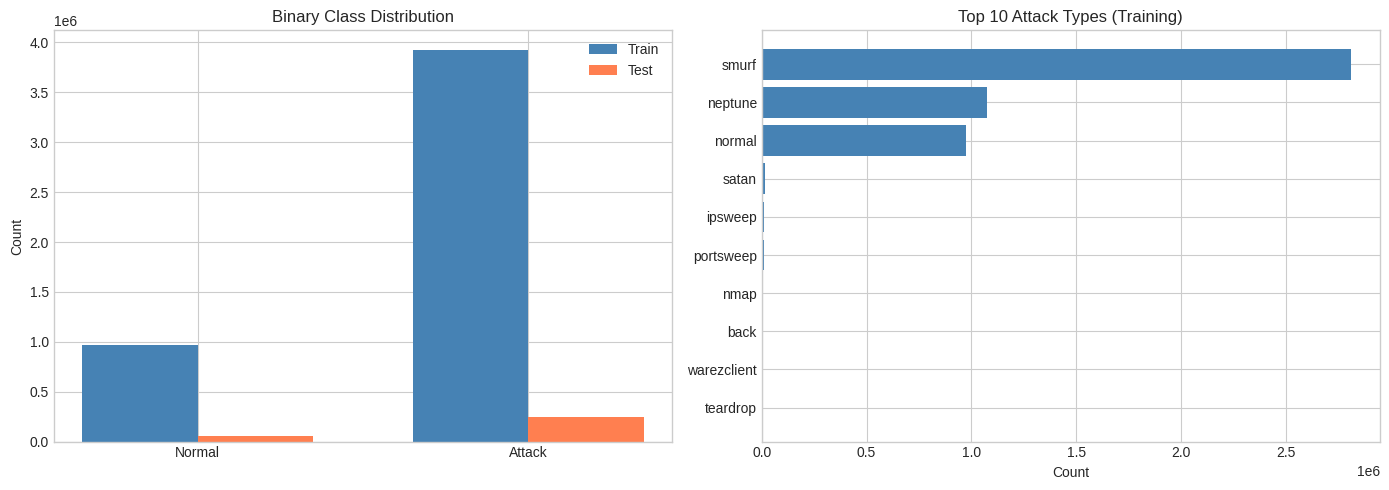

In [30]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary distribution
labels = ['Normal', 'Attack']
train_vals = [train_class_dist.get(0, 0), train_class_dist.get(1, 0)]
test_vals = [test_class_dist.get(0, 0), test_class_dist.get(1, 0)]

x = np.arange(len(labels))
width = 0.35

axes[0].bar(x - width/2, train_vals, width, label='Train', color='steelblue')
axes[0].bar(x + width/2, test_vals, width, label='Test', color='coral')
axes[0].set_ylabel('Count')
axes[0].set_title('Binary Class Distribution')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()

# Top attack types
top_attacks = attack_dist.head(10)
axes[1].barh(range(len(top_attacks)), top_attacks.values, color='steelblue')
axes[1].set_yticks(range(len(top_attacks)))
axes[1].set_yticklabels(top_attacks.index)
axes[1].set_xlabel('Count')
axes[1].set_title('Top 10 Attack Types (Training)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Feature Analysis

In [31]:
print("=" * 60)
print("FEATURE ANALYSIS")
print("=" * 60)

# Identify feature types
categorical_cols = ['protocol_type', 'service', 'flag']
binary_cols = ['land', 'logged_in', 'root_shell', 'su_attempted', 'is_host_login', 'is_guest_login']
numeric_cols = [c for c in COLUMN_NAMES[:-1] if c not in categorical_cols + binary_cols]

print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Binary features ({len(binary_cols)}): {binary_cols}")
print(f"Numeric features ({len(numeric_cols)}): {len(numeric_cols)} columns")

FEATURE ANALYSIS

Categorical features (3): ['protocol_type', 'service', 'flag']
Binary features (6): ['land', 'logged_in', 'root_shell', 'su_attempted', 'is_host_login', 'is_guest_login']
Numeric features (32): 32 columns


In [32]:
# Categorical feature analysis
print("\n--- Categorical Features ---")
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df_train[col].nunique()}")
    print(f"  Top 5: {df_train[col].value_counts().head().to_dict()}")


--- Categorical Features ---

protocol_type:
  Unique values: 3
  Top 5: {'icmp': 2833545, 'tcp': 1870598, 'udp': 194288}

service:
  Unique values: 70
  Top 5: {'ecr_i': 2811660, 'private': 1100831, 'http': 623091, 'smtp': 96554, 'other': 72653}

flag:
  Unique values: 11
  Top 5: {'SF': 3744328, 'S0': 869829, 'REJ': 268874, 'RSTR': 8094, 'RSTO': 5344}


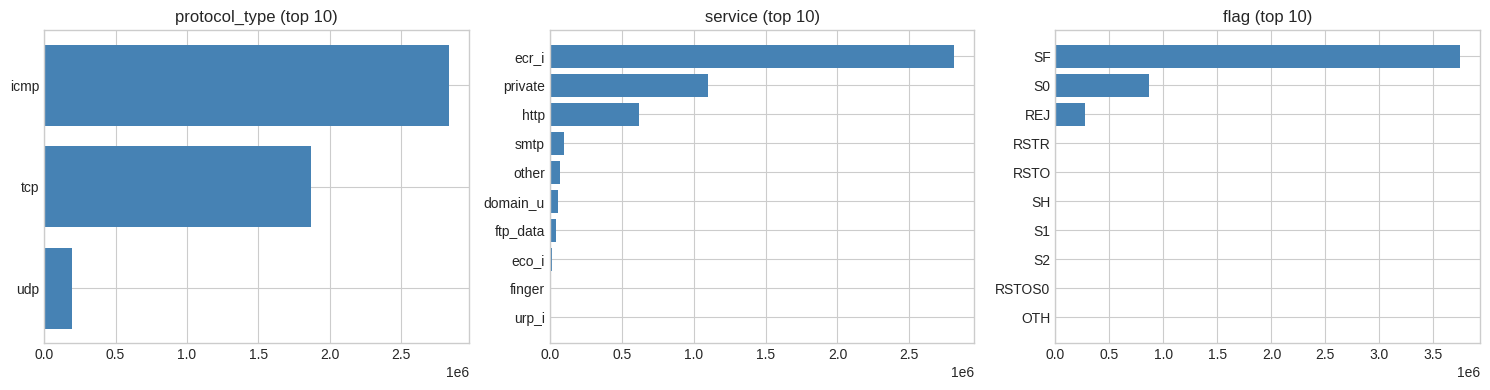

In [33]:
# Visualize categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(categorical_cols):
    top_vals = df_train[col].value_counts().head(10)
    axes[i].barh(range(len(top_vals)), top_vals.values, color='steelblue')
    axes[i].set_yticks(range(len(top_vals)))
    axes[i].set_yticklabels(top_vals.index)
    axes[i].set_title(f'{col} (top 10)')
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

In [34]:
# Numerical feature statistics
print("\n--- Numerical Features Statistics ---")
df_train[numeric_cols].describe().T


--- Numerical Features Statistics ---


,count,mean,std,min,25%,50%,75%,max
duration,4898431.0,48.342430,723.329811,0.0,0.00,0.0,0.00,5.832900e+04
src_bytes,4898431.0,1834.621175,941431.074491,0.0,45.00,520.0,1032.00,1.379964e+09
dst_bytes,4898431.0,1093.622814,645012.333743,0.0,0.00,0.0,0.00,1.309937e+09
wrong_fragment,4898431.0,0.000649,0.042854,0.0,0.00,0.0,0.00,3.000000e+00
urgent,4898431.0,0.000008,0.007215,0.0,0.00,0.0,0.00,1.400000e+01
hot,4898431.0,0.012438,0.468978,0.0,0.00,0.0,0.00,7.700000e+01
num_failed_logins,4898431.0,0.000032,0.007299,0.0,0.00,0.0,0.00,5.000000e+00
num_compromised,4898431.0,0.008088,3.856481,0.0,0.00,0.0,0.00,7.479000e+03
num_root,4898431.0,0.012935,3.938075,0.0,0.00,0.0,0.00,7.468000e+03
num_file_creations,4898431.0,0.001189,0.124186,0.0,0.00,0.0,0.00,4.300000e+01


In [35]:
# Check for zero-variance features
print("\n--- Zero/Low Variance Features ---")
for col in numeric_cols:
    variance = df_train[col].var()
    unique_count = df_train[col].nunique()
    if unique_count <= 2 or variance < 0.01:
        print(f"{col}: variance={variance:.4f}, unique={unique_count}")


--- Zero/Low Variance Features ---
wrong_fragment: variance=0.0018, unique=3
urgent: variance=0.0001, unique=6
num_failed_logins: variance=0.0001, unique=6
num_shells: variance=0.0001, unique=3
num_access_files: variance=0.0013, unique=10
num_outbound_cmds: variance=0.0000, unique=1
diff_srv_rate: variance=0.0068, unique=95
dst_host_srv_diff_host_rate: variance=0.0017, unique=76


## 6. Correlation Analysis

In [36]:
print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Compute correlation matrix for numeric features
# Sample for faster computation
df_sample = df_train.sample(min(100000, len(df_train)), random_state=42)
corr_matrix = df_sample[numeric_cols].corr()

# Find highly correlated pairs
print("\n--- Highly Correlated Feature Pairs (|r| > 0.9) ---")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{f1} <-> {f2}: r = {r:.4f}")

CORRELATION ANALYSIS

--- Highly Correlated Feature Pairs (|r| > 0.9) ---
srv_serror_rate <-> dst_host_srv_serror_rate: r = 0.9995
serror_rate <-> dst_host_serror_rate: r = 0.9991
serror_rate <-> srv_serror_rate: r = 0.9984
serror_rate <-> dst_host_srv_serror_rate: r = 0.9981
dst_host_serror_rate <-> dst_host_srv_serror_rate: r = 0.9981
srv_serror_rate <-> dst_host_serror_rate: r = 0.9979
rerror_rate <-> srv_rerror_rate: r = 0.9953
rerror_rate <-> dst_host_rerror_rate: r = 0.9891
srv_rerror_rate <-> dst_host_srv_rerror_rate: r = 0.9882
dst_host_rerror_rate <-> dst_host_srv_rerror_rate: r = 0.9859
rerror_rate <-> dst_host_srv_rerror_rate: r = 0.9858
srv_rerror_rate <-> dst_host_rerror_rate: r = 0.9846
dst_host_srv_count <-> dst_host_same_srv_rate: r = 0.9792
srv_count <-> dst_host_same_src_port_rate: r = 0.9471
count <-> srv_count: r = 0.9427
same_srv_rate <-> dst_host_same_srv_rate: r = 0.9330
same_srv_rate <-> dst_host_srv_count: r = 0.9095


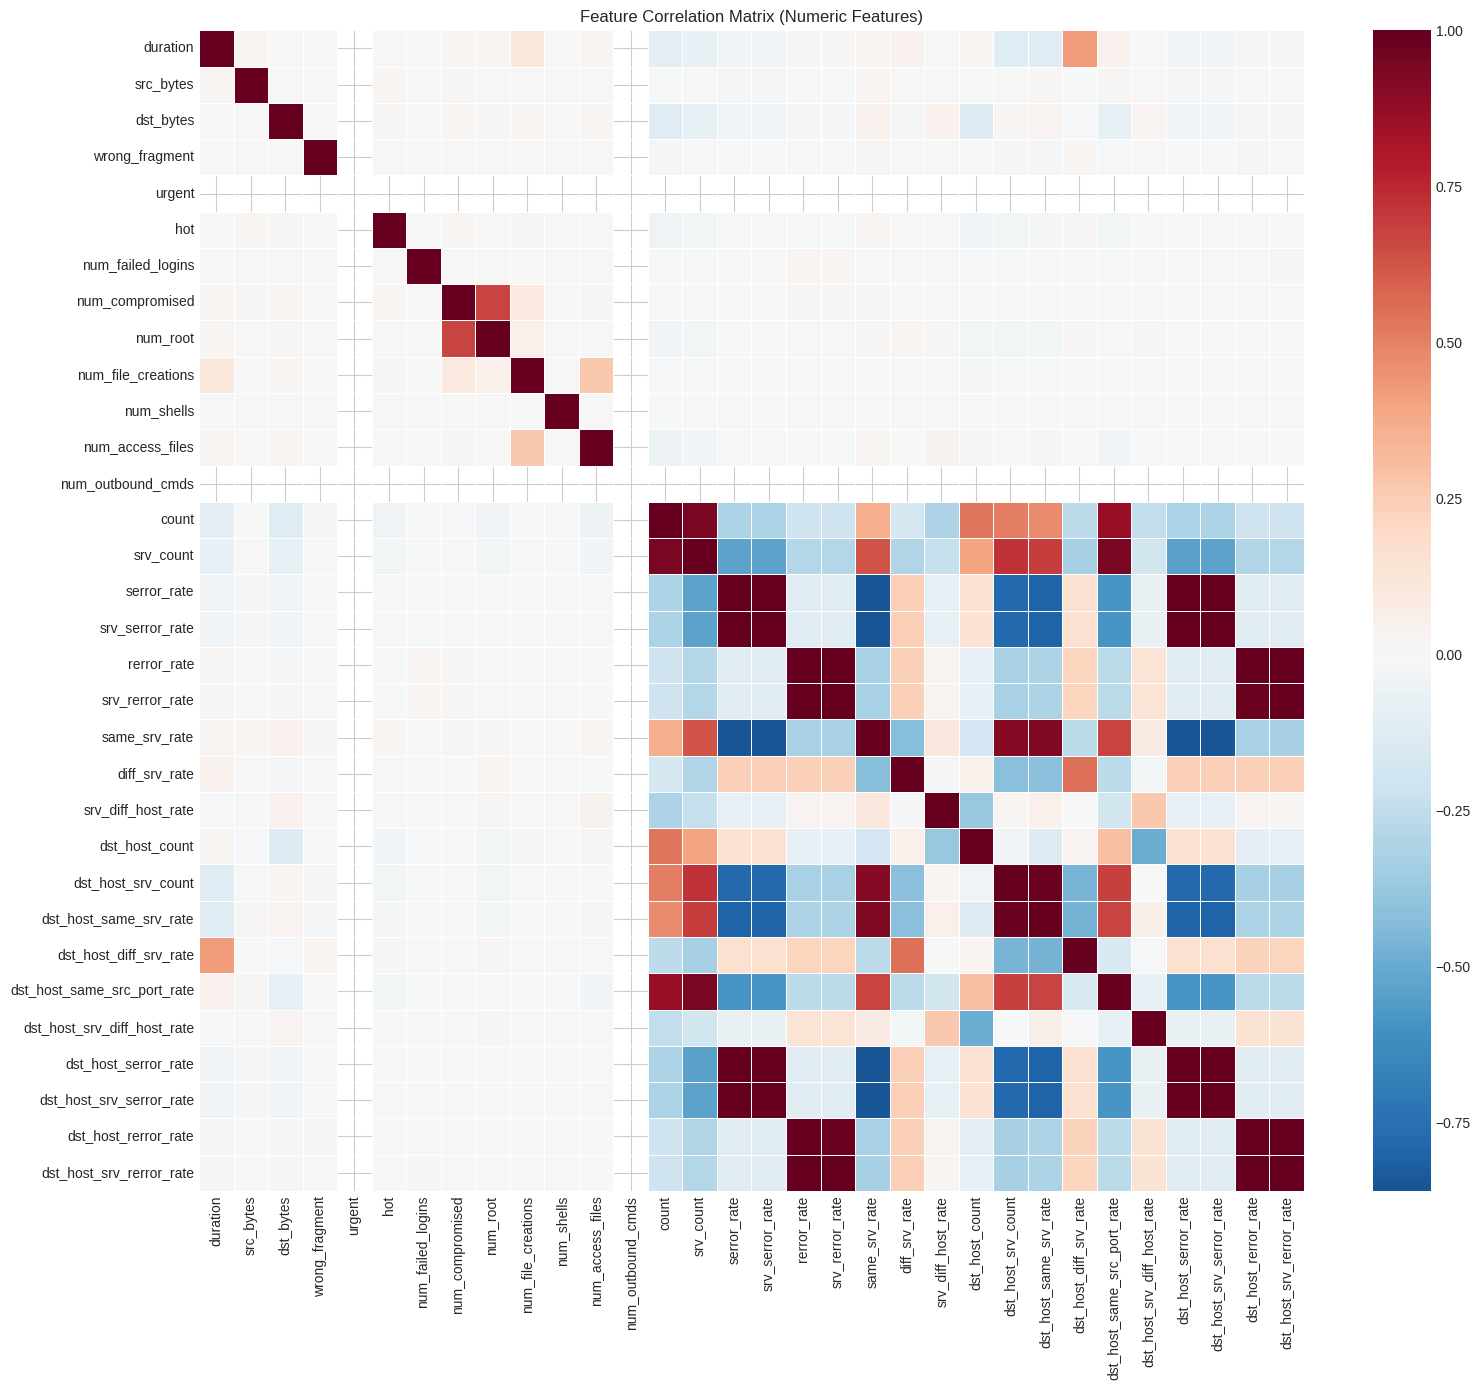

In [37]:
# Correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, 
            xticklabels=True, yticklabels=True,
            linewidths=0.5)
plt.title('Feature Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

In [38]:
# Correlation with target
print("\n--- Correlation with Target (is_attack) ---")
target_corr = df_sample[numeric_cols + ['is_attack']].corr()['is_attack'].drop('is_attack')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("\nTop 10 features correlated with attack:")
for feat in target_corr_sorted.head(10).index:
    print(f"  {feat}: r = {target_corr[feat]:.4f}")


--- Correlation with Target (is_attack) ---

Top 10 features correlated with attack:
  count: r = 0.7669
  dst_host_count: r = 0.6550
  srv_count: r = 0.5740
  dst_host_same_src_port_rate: r = 0.4859
  srv_diff_host_rate: r = -0.3655
  same_srv_rate: r = -0.2518
  dst_host_srv_serror_rate: r = 0.2311
  serror_rate: r = 0.2306
  srv_serror_rate: r = 0.2304
  dst_host_serror_rate: r = 0.2304


## 7. Outlier Detection

In [39]:
print("=" * 60)
print("OUTLIER ANALYSIS")
print("=" * 60)

# IQR-based outlier detection
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    return outliers, outliers / len(series) * 100

print("\n--- Outlier Count per Feature (IQR method) ---")
outlier_stats = []
for col in numeric_cols:
    count, pct = count_outliers_iqr(df_train[col])
    outlier_stats.append({'feature': col, 'outliers': count, 'percentage': pct})

outlier_df = pd.DataFrame(outlier_stats).sort_values('percentage', ascending=False)
print(outlier_df.head(15).to_string(index=False))

OUTLIER ANALYSIS

--- Outlier Count per Feature (IQR method) ---
                    feature  outliers  percentage
              diff_srv_rate   1118172   22.827146
              same_srv_rate   1117546   22.814366
       dst_host_serror_rate    932408   19.034830
   dst_host_srv_serror_rate    925147   18.886599
                serror_rate    890112   18.171370
            srv_serror_rate    882556   18.017116
                  dst_bytes    833577   17.017224
             dst_host_count    593416   12.114410
dst_host_srv_diff_host_rate    513949   10.492115
         srv_diff_host_rate    338702    6.914500
       dst_host_rerror_rate    327395    6.683671
   dst_host_srv_rerror_rate    322474    6.583210
            srv_rerror_rate    290604    5.932594
                rerror_rate    287250    5.864123
                   duration    118939    2.428104


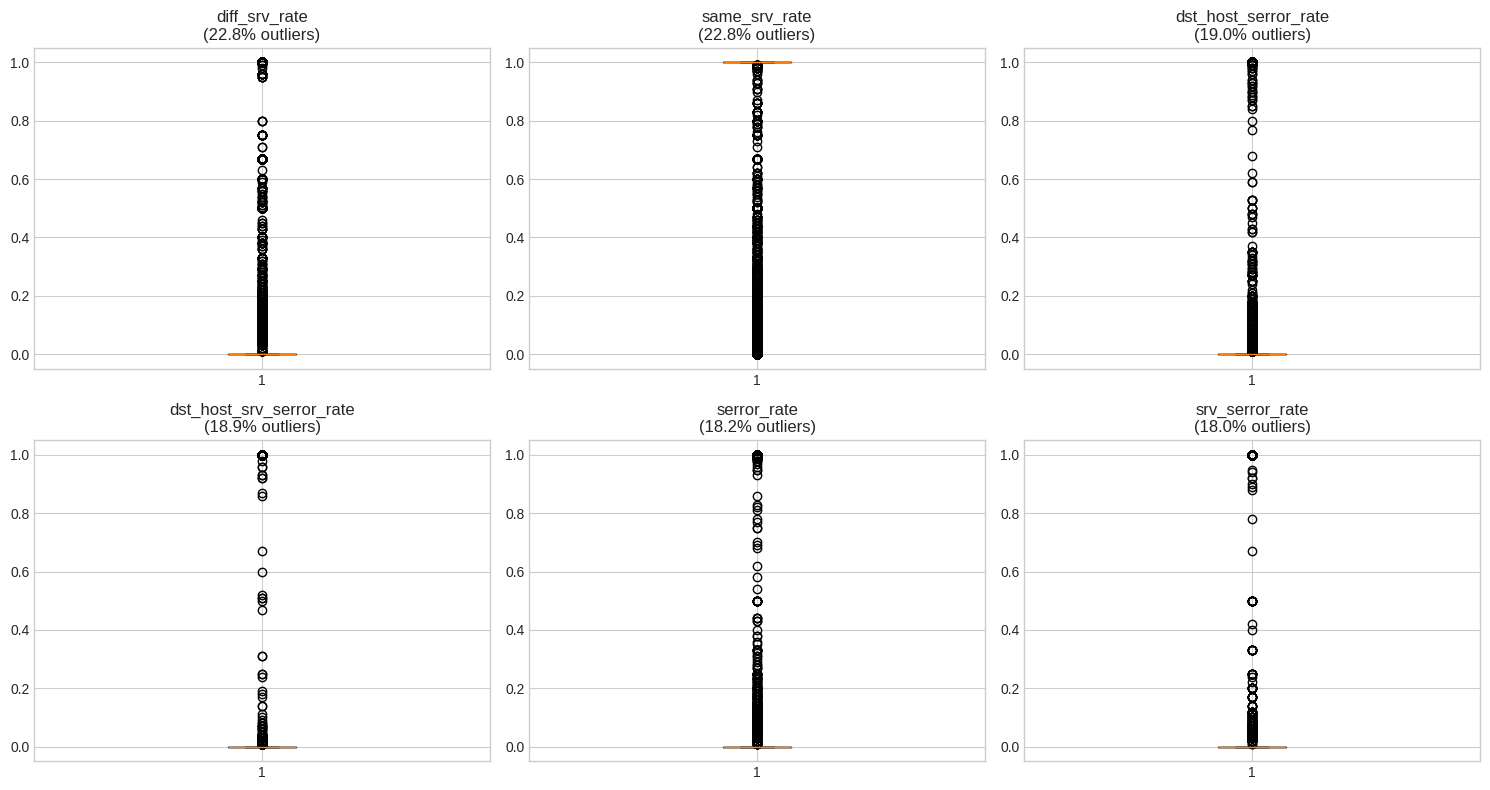

In [40]:
# Visualize distribution of features with most outliers
top_outlier_features = outlier_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_outlier_features):
    axes[i].boxplot(df_sample[col].values, vert=True)
    axes[i].set_title(f'{col}\n({outlier_df[outlier_df.feature==col].percentage.values[0]:.1f}% outliers)')

plt.tight_layout()
plt.show()

## 8. Feature Importance (Random Forest)

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

# Prepare data (sample for speed)
df_sample = df_train.sample(min(50000, len(df_train)), random_state=42).copy()

# Encode categorical features
for col in categorical_cols:
    le = LabelEncoder()
    df_sample[col] = le.fit_transform(df_sample[col].astype(str))

X = df_sample[COLUMN_NAMES[:-1]]
y = df_sample['is_attack']

# Train Random Forest
print("\nTraining Random Forest for feature importance...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Feature importance
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(importance.head(15).to_string(index=False))

FEATURE IMPORTANCE

Training Random Forest for feature importance...

Top 15 Most Important Features:
                    feature  importance
                      count    0.190707
                  dst_bytes    0.129263
                  logged_in    0.128307
              protocol_type    0.058348
             dst_host_count    0.056789
                  srv_count    0.049790
dst_host_srv_diff_host_rate    0.047189
                  src_bytes    0.044016
dst_host_same_src_port_rate    0.036414
              diff_srv_rate    0.036288
                       flag    0.036187
         dst_host_srv_count    0.030431
     dst_host_same_srv_rate    0.028911
              same_srv_rate    0.026280
                    service    0.019472


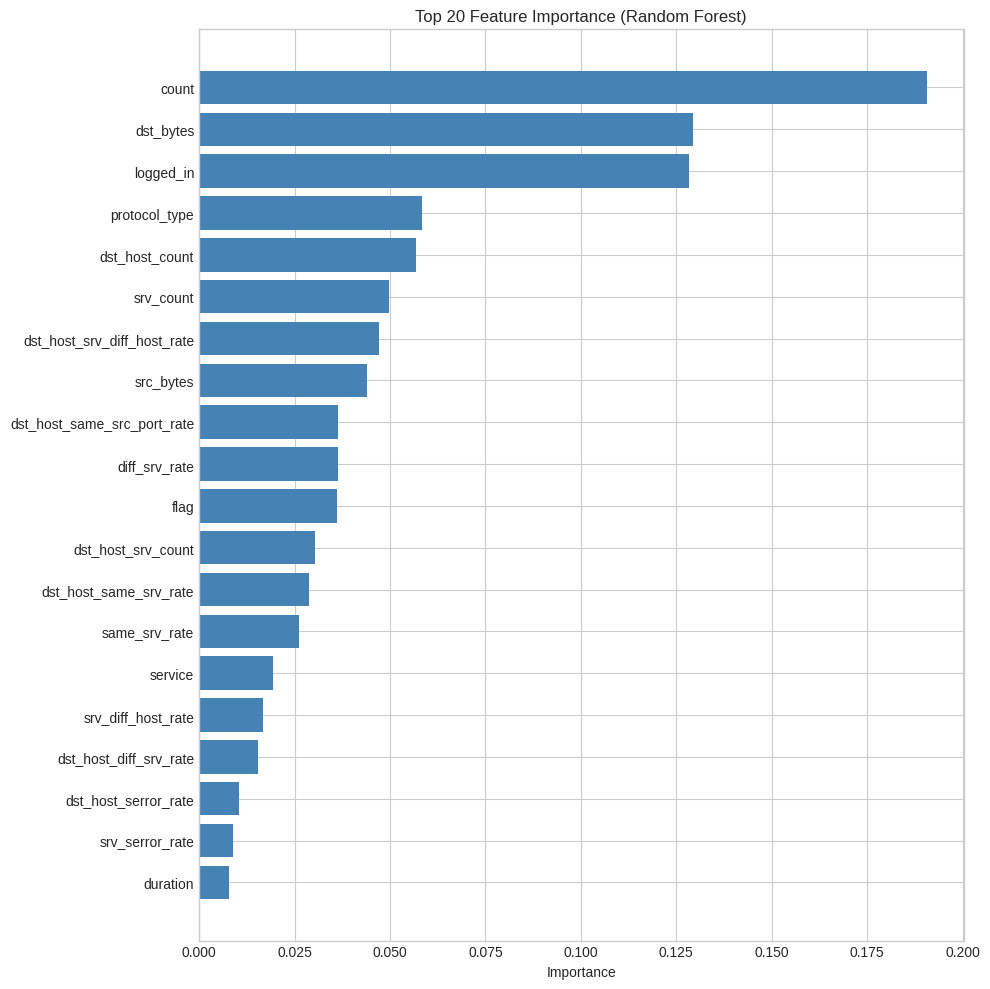

In [42]:
# Visualize feature importance
plt.figure(figsize=(10, 10))
top_20 = importance.head(20)
plt.barh(range(len(top_20)), top_20['importance'].values, color='steelblue')
plt.yticks(range(len(top_20)), top_20['feature'].values)
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()